# Itau Quant Challenge 2025 - Pipeline End-to-End

Este notebook executa o processo completo do repositorio, explicando cada etapa e salvando artefatos em `reports/`.

Etapas:
- Carregar configuracao e dados
- Rodar backtest base e exibir KPIs
- Walk-forward validation
- Heatmaps de sensibilidade de parametros
- Stress de custos de transacao
- Capacity curve
- (Opcional) PDF consolidado do relatorio


In [1]:
import os
for env in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[env] = "1"
os.environ["PYTHONHASHSEED"] = "0"

In [2]:
import features, importlib, sys
print("features from:", features.__file__)
import features.tda as tda, features.factors as fac
print("has get_alphas_from_cfg?", hasattr(fac, "get_alphas_from_cfg"))
print("TFIParams.from_config?", hasattr(tda.TFIParams, "from_config"))
print(sys.path[:3])


features from: D:\GitHub Dic\itau-quant-challenge-2025\src\features\__init__.py
has get_alphas_from_cfg? True
TFIParams.from_config? True
['D:\\GitHub Dic\\itau-quant-challenge-2025\\src', 'C:\\Users\\felip\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\felip\\AppData\\Local\\Programs\\Python\\Python312\\DLLs']


In [3]:
# Setup
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

import os; os.environ["REGIME_GAIN"] = "2"
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Execute a partir do repo root ou da pasta notebooks/'
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', ROOT)
print('Reports dir:', REPORTS_DIR)

Repo root: d:\GitHub Dic\itau-quant-challenge-2025
Reports dir: d:\GitHub Dic\itau-quant-challenge-2025\reports


## Configuracao
Carrega o YAML de configuracao base do projeto.

In [4]:
from dataio.config import load_config

CONFIG_PATH = ROOT / 'configs' / 'base.yaml'
cfg = load_config(str(CONFIG_PATH))
print('Config carregada:', CONFIG_PATH)
print('Datas:', cfg.get('dates'))
cfg

Config carregada: d:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Datas: {'start': datetime.date(2017, 9, 4), 'end': datetime.date(2025, 10, 6)}


{'portfolio': {'method': 'hrp',
  'periphery_bias_lambda': 1.0,
  'expected_returns': {'enabled': True,
   'max_tilt': 0.03,
   'min_signal_z': 0.0,
   'regime_gate': 0.0,
   'risk_aversion': 2.5,
   'long_only': True}},
 'data': {'source': 'local_csv'},
 'paths': {'data': './data',
  'reports': './reports',
  'artifacts': './artifacts'},
 'seeds': 42,
 'backtest': {'rolling_training': {'enabled': True,
   'in_sample_days': 504,
   'out_of_sample_days': 126}},
 'dates': {'start': datetime.date(2017, 9, 4),
  'end': datetime.date(2025, 10, 6)},
 'tda': {'delay': 1,
  'dim': 2,
  'n_cubes': 2,
  'overlap': 0.2,
  'epsilon': None,
  'min_samples': 4,
  'window': 168,
  'eps_quantile': 0.15,
  'smooth_span': 10,
  'n_jobs': -1},
 'tda_ph': {'enabled': True,
  'window': 30,
  'homology_dim': 1,
  'norm': 'l2',
  'smooth_span': 10,
  'zscore_lookback': 250,
  'alert_sigma': 0.58,
  'riskoff_sigma': 1.8},
 'mapper': {'enabled': True,
  'lens': 'pca_umap',
  'n_cubes': 2,
  'overlap': 0.2,
  '

## Dados
Carrega o painel de mercado. Se o `get_panel` falhar, cai para dados sinteticos. Exibe um preview e o intervalo de datas.

In [5]:
from main import _load_panel as _load_panel

panel = _load_panel(cfg)
date_level = 'date' if 'date' in panel.index.names else panel.index.names[0]
print('Panel shape:', panel.shape)
print('Date range:', panel.index.get_level_values(date_level).min(), '->', panel.index.get_level_values(date_level).max())
panel.sort_index().head()

Panel shape: (137210, 2)
Date range: 2017-09-04 00:00:00 -> 2025-10-06 00:00:00


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

## Backtest Base
Executa o backtest principal, plota a equity e salva artefatos em `reports/`.

Rolling backtest ativo: 504 dias in-sample / 126 dias out-of-sample


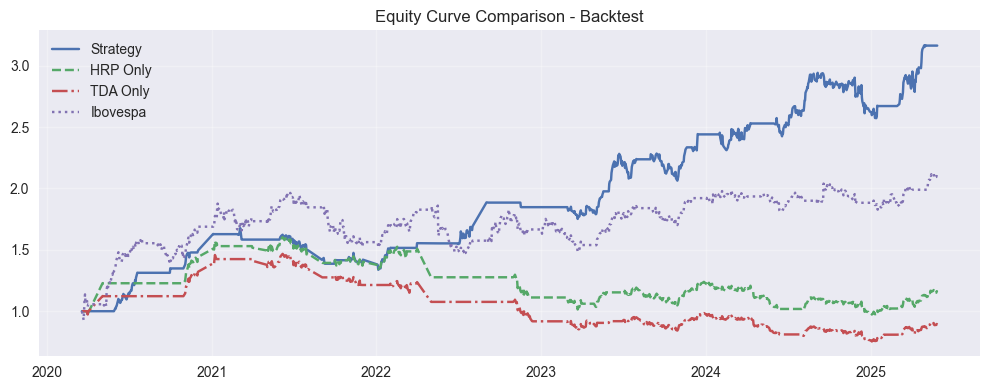

**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**

,CAGR,Sharpe,Sortino,Vol,MaxDD,Calmar,HitRate,Turnover
Strategy,0.291656,1.637371,2.009453,0.164707,-0.202343,1.441394,0.541237,0.018157
HRP Only,0.033075,0.259759,0.283488,0.200212,-0.392887,0.084185,0.532164,0.011799
TDA Only,-0.025247,-0.070203,-0.070556,0.16647,-0.486406,-0.051904,0.515789,0.01165
Ibovespa,0.180296,0.846098,1.153875,0.22607,-0.254772,0.707673,0.516129,<NA>


Comparacao salva em: D:\GitHub Dic\itau-quant-challenge-2025\reports\equity_curve_comparison.png


In [ ]:
from copy import deepcopy
from backtest.engine import run_backtest
from reports import plot_equity_curves, table_kpis

rolling_cfg = (cfg.get('backtest', {}) or {}).get('rolling_training', {}) or {}
if rolling_cfg.get('enabled'):
    is_days = rolling_cfg.get('in_sample_days', rolling_cfg.get('train_days', '??'))
    oos_days = rolling_cfg.get('out_of_sample_days', rolling_cfg.get('test_days', '??'))
    print(f'Rolling backtest ativo: {is_days} dias in-sample / {oos_days} dias out-of-sample')

bt = run_backtest(cfg, panel=panel)
equity = bt['equity_curve']
returns = equity.pct_change().dropna()

hrp_cfg = deepcopy(cfg)
hrp_portfolio = hrp_cfg.setdefault('portfolio', {})
hrp_portfolio['method'] = 'hrp_only'
hrp_portfolio.setdefault('hrp_only_regime_value', 0.5)

tda_cfg = deepcopy(cfg)
tda_cfg.setdefault('portfolio', {})['method'] = 'tda_only'

bt_hrp = run_backtest(hrp_cfg, panel=panel)
equity_hrp = bt_hrp['equity_curve']
returns_hrp = equity_hrp.pct_change().dropna()

bt_tda = run_backtest(tda_cfg, panel=panel)
equity_tda = bt_tda['equity_curve']
returns_tda = equity_tda.pct_change().dropna()

ibov_path = (ROOT / 'data' / 'benchmark' / 'ibovespa_index_b3.csv').resolve()
ibov_prices = (
    pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
    .sort_index()
)
ibov_prices_aligned = ibov_prices.reindex(equity.index).ffill()
if ibov_prices_aligned.isna().all():
    raise ValueError('Ibovespa benchmark does not overlap with backtest dates.')
ibov_equity = (ibov_prices_aligned / ibov_prices_aligned.iloc[0]).rename('Ibovespa')
ibov_returns = ibov_equity.pct_change().fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity.index, equity.values, label='Strategy')
ax.plot(equity_hrp.index, equity_hrp.values, label='HRP Only', linestyle='--')
ax.plot(equity_tda.index, equity_tda.values, label='TDA Only', linestyle='-.')
ax.plot(ibov_equity.index, ibov_equity.values, label='Ibovespa', linestyle=':')
ax.set_title('Equity Curve Comparison - Backtest')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

kpi = table_kpis({
    'Strategy': {
        'equity_curve': equity,
        'returns': returns,
        'weights': bt.get('daily_positions')
    },
    # 'HRP Only': {
    #     'equity_curve': equity_hrp,
    #     'returns': returns_hrp,
    #     'weights': bt_hrp.get('daily_positions')
    # },
    # 'TDA Only': {
    #     'equity_curve': equity_tda,
    #     'returns': returns_tda,
    #     'weights': bt_tda.get('daily_positions')
    # },
    'Ibovespa': {
        'equity_curve': ibov_equity,
        'returns': ibov_returns,
        'weights': None
    }
})
display(Markdown('**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**'))
display(kpi)

comparison_png = plot_equity_curves(
    {
        'Strategy': equity,
        # 'HRP Only': equity_hrp,
        # 'TDA Only': equity_tda,
        'Ibovespa': ibov_equity,
    },
    filename='equity_curve_comparison.png'
)
print('Comparacao salva em:', comparison_png)

## Walk-Forward Validation
Executa validacao walk-forward (2 anos in-sample / 6 meses out-of-sample). Mostra equity e KPIs agregados.

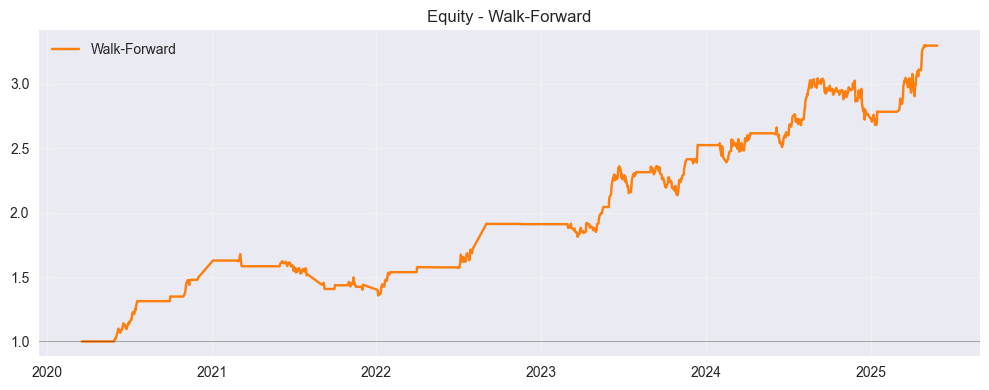

**KPIs - Walk-Forward**

,Valor
CAGR,0.303394
Sharpe,1.696032
Sortino,2.069535
Vol,0.164163
MaxDD,-0.190751
AvgTimeUnderWater,22.441860
MaxTimeUnderWater,264.000000
Calmar,1.590523
HitRate,0.544041
Turnover,0.018157


**Janelas Walk-Forward (amostra)**

,is_start,is_end,oos_start,oos_end,kpis,config,meta
0,2017-09-04,2020-03-18,2020-03-19,2020-11-16,"{'final_equity': 1.4784635101093138, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2017-09-04T00:00:00', 'end': '2020-..."
1,2018-05-14,2020-11-16,2020-11-17,2021-07-16,"{'final_equity': 1.0345634494547435, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2018-05-14T00:00:00', 'end': '2021-..."
2,2018-12-14,2021-07-16,2021-07-19,2022-03-18,"{'final_equity': 0.9909174843638683, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2018-12-14T00:00:00', 'end': '2022-..."
3,2019-07-23,2022-03-18,2022-03-21,2022-11-16,"{'final_equity': 1.2434138706605427, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2019-07-23T00:00:00', 'end': '2022-..."
4,2020-03-19,2022-11-16,2022-11-17,2023-05-19,"{'final_equity': 1.0486284886523403, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2020-03-19T00:00:00', 'end': '2023-..."


In [7]:
from validation import run_walk_forward

wf = run_walk_forward(cfg, panel)
walk_equity = wf['equity_curve']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(walk_equity.index, walk_equity.values, color='#ff7f0e', label='Walk-Forward')
ax.axhline(1.0, color='black', linewidth=0.8, alpha=0.3)
ax.set_title('Equity - Walk-Forward')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown('**KPIs - Walk-Forward**'))
display(pd.DataFrame(wf['kpis'], index=['Valor']).T)

windows_df = pd.DataFrame(wf['windows'])
display(Markdown('**Janelas Walk-Forward (amostra)**'))
display(windows_df.head())

### Funcoes auxiliares para grids customizados
Utilidades genericas para montar grids 2D de parametros (kill switch, caps do HRP, etc.), extraindo metricas financeiras e salvando os artefatos em `reports/parameter_sweeps`.

In [8]:
from reports.heatmaps import run_two_param_heatmaps, run_param_grid

reports_dir = REPORTS_DIR / 'parameter_sweeps'
reports_dir.mkdir(parents=True, exist_ok=True)


## TDA - Heatmaps de Sensibilidade
Explora combinacoes dos hiperparametros de `tda_ph` e `mapper`. Cada grid roda o backtest com os novos parametros e renderiza as figuras diretamente aqui para comparacao rapida.

In [9]:
# tda_grids = [
    
#     #"name": "tda_ph.alert_sigma vs tda_ph.riskoff_sigma", "grid": {"tda_ph.alert_sigma":  [0.514, 0.570, 0.596, 0.622], "tda_ph.riskoff_sigma": [1.700, 1.737, 1.774, 1.811, 1.848, 1885]}},
#     #{"name": "mapper.min_cluster_size vs mapper.eps_quantile", "grid": {"mapper.min_cluster_size": [6, 8, 10, 12, 14, 16, 18, 20, 22, 24], "mapper.eps_quantile": [0.260, 0.273, 0.292, 0.304, 0.317, 0.329, 0.342, 0.355, 0.367, 0.380]}},
#     #{"name": "tda_ph.window vs tda_ph.zscore_lookback", "grid": {"tda_ph.window": [24, 25, 26, 27, 28, 29, 30, 31, 32, 33,34, 35, 36, 37, 38, 39, 40, 41, 42, 44], "tda_ph.zscore_lookback": [250, 254, 258, 262, 266, 271, 275, 279, 283, 287,292, 296, 300, 304, 308, 313, 317, 321, 325, 330]}},
#     #{"name": "tda_ph.alert_sigma vs tda_ph.riskoff_sigma", "grid": {"tda_ph.alert_sigma": [1.2], "tda_ph.riskoff_sigma": [1.2, 1.4, 1.6, 1.8]}},
#     {"name": "tda_ph.alert_sigma vs tda_ph.riskoff_sigma", "grid": {"tda_ph.alert_sigma": [10.58], "tda_ph.overlap": [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]}},
#     #{"name": "tda_ph.window vs tda_ph.zscore_lookback", "grid": {"tda_ph.window": [30,45,60,75], "tda_ph.zscore_lookback": [150,200,250,300]}},
#     #{"name": "mapper.n_cubes vs mapper.eps_quantile", "grid": {"mapper.n_cubes": [4,8,12,16], "mapper.eps_quantile": [0.1,0.18,0.24,0.36]}},
#     #{"name": "mapper.n_cubes vs tda_ph.smooth_span", "grid": {"tda_ph.n_cubes": [3, 7, 11, 15], "tda_ph.smooth_span": [4, 8, 12, 16]}},
#     #{"name": "tda_ph.n_cubes vs tda_ph.norm", "grid": {"tda_ph.n_cubes": [3, 7, 11, 15], "tda_ph.norm": ['l1', 'l2']}},         # heatmap ainda n aceita string
# ]

# tda_runs = {}
# for entry in tda_grids:
#     name = entry["name"]
#     grid = entry["grid"]
#     prefix = name.replace(" ", "_").replace(".", "-").replace("/", "-")
#     display(Markdown(f"**Grid {name}** - parametros {list(grid.keys())}"))
#     results_df, heatmaps = run_two_param_heatmaps(
#         cfg,
#         panel,
#         grid,
#         report_prefix=f"tda_{prefix}",
#         plot_metrics=("sharpe", "max_drawdown"),
#     )
#     tda_runs[name] = {"results": results_df, "heatmaps": heatmaps}
#     display(results_df.sort_values("sharpe", ascending=False).head())
#     for metric, path in heatmaps.items():
#         display(Markdown(f"{metric.title()} heatmap: `{path}`"))
#         display(Image(filename=str(path), width=420))

# tda_summary = pd.DataFrame(
#     [
#         {"grid": name, "metric": metric, "path": str(path)}
#         for name, payload in tda_runs.items()
#         for metric, path in payload["heatmaps"].items()
#     ]
# )
# display(Markdown("**Arquivos de heatmap (TDA)**"))
# display(tda_summary)


## Kill Switch - Sensibilidade de Parametros
Varre combinacoes relevantes dos limites de drawdown/vol e da janela de monitoramento para verificar impacto em Sharpe e MaxDD.

In [10]:
# import numpy as np

# # Atualize os valores *_star apos cada heatmap sequencial
# mdd_thres_star = -0.15  # substitua apos o heatmap 1
# vol_mult_star = 1.60     # substitua apos o heatmap 2
# cooldown_star = 21       # substitua apos o heatmap 3

# lookback_dense = [int(round(v)) for v in np.linspace(45, 120, 20)]
# mdd_thres_wide = [round(float(v), 4) for v in np.linspace(-0.12, -0.25, 20)]
# vol_mult_wide = [round(float(v), 3) for v in np.linspace(1.4, 2.0, 20)]
# cooldown_grid = list(range(10, 30))
# mdd_thres_local = [
#     round(float(v), 4)
#     for v in np.linspace(mdd_thres_star - 0.02, mdd_thres_star + 0.02, 20)
# ]
# vol_mult_local = [
#     round(float(v), 3)
#     for v in np.linspace(
#         max(1.3, vol_mult_star - 0.10),
#         min(2.1, vol_mult_star + 0.10),
#         20,
#     )
# ]
# cooldown_local = [
#     int(round(v))
#     for v in np.linspace(
#         max(8, cooldown_star - 4),
#         min(35, cooldown_star + 4),
#         20,
#     )
# ]
# reentry_grid = [round(float(v), 4) for v in np.linspace(0.03, 0.08, 20)]

# kill_switch_grids = {
#     '01_lookback_vs_thres': {
#         'risk.mdd_lookback': lookback_dense,
#         'risk.mdd_thres': mdd_thres_wide,
#     },
#     '02_thres_vs_vol': {
#         'risk.mdd_thres': mdd_thres_local,
#         'risk.vol_mult': vol_mult_wide,
#     },
#     '03_vol_vs_cooldown': {
#         'risk.vol_mult': vol_mult_local,
#         'risk.cooldown_days': cooldown_grid,
#     },
#     '04_cooldown_vs_hysteresis': {
#         'risk.cooldown_days': cooldown_local,
#         'risk.reentry_hysteresis': reentry_grid,
#     },
# }

# kill_switch_runs = {}
# for label, grid in kill_switch_grids.items():
#     prefix = f"kill_switch_{label}"
#     friendly = label.replace('_', ' ').title()
#     display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
#     results_df, heatmaps = run_two_param_heatmaps(
#         cfg,
#         panel,
#         grid,
#         report_prefix=prefix,
#         plot_metrics=('sharpe', 'max_drawdown'),
#     )
#     kill_switch_runs[label] = {'results': results_df, 'heatmaps': heatmaps}
#     display(results_df.sort_values('sharpe', ascending=False).head())
#     for metric, path in heatmaps.items():
#         display(Markdown(f"{metric.title()} heatmap: `{path}`"))
#         display(Image(filename=str(path), width=420))

# kill_switch_summary = pd.DataFrame(
#     [
#         {'grid': label, 'metric': metric, 'path': str(path)}
#         for label, payload in kill_switch_runs.items()
#         for metric, path in payload['heatmaps'].items()
#     ]
# )
# display(Markdown('**Arquivos de heatmap do kill switch**'))
# display(kill_switch_summary)


## Mini Heatmaps Rapidos
Executa varreduras pequenas para preencher o historico de hiperparametros rapidamente antes da analise de correlacao.

In [11]:
# from reports.heatmaps import run_two_param_heatmaps
# RUN_MINI_HEATMAPS = True

# if RUN_MINI_HEATMAPS:
#     mini_grids = {
#         'risk_quick': {
#             'risk.vol_mult': [1.5, 1.7],
#             'risk.mdd_thres': [-0.16, -0.14],
#         },
#         'tda_quick': {
#             'tda.window': [150, 180],
#             'tda.overlap': [0.15, 0.25],
#         },
#         'mapper_quick': {
#             'mapper.n_cubes': [4, 6],
#             'mapper.overlap': [0.2, 0.4],
#         },
#     }
#     mini_runs = {}
#     for label, grid in mini_grids.items():
#         prefix = f"quick_{label}"
#         display(Markdown(f"**Mini grid {label}** - parametros {list(grid.keys())}"))
#         results_df, heatmaps = run_two_param_heatmaps(
#             cfg,
#             panel,
#             grid,
#             report_prefix=prefix,
#             plot_metrics=('sharpe',),
#         )
#         mini_runs[label] = {'results': results_df, 'heatmaps': heatmaps}
#         display(results_df)
#         for metric, path in heatmaps.items():
#             display(Markdown(f"{metric.title()} heatmap: `{path}`"))
#             display(Image(filename=str(path), width=280))
# else:
#     display(Markdown('> Mini heatmaps desativados. Ajuste RUN_MINI_HEATMAPS para executar.'))


## Portfolio Parameter Sweeps
Varre combinacoes maiores de parametros do bloco `portfolio` para alimentar a analise de correlacao.

In [12]:
# from reports.heatmaps import run_param_grid
# portfolio_grids = [
#     (
#         'portfolio_exposure',
#         {
#             'portfolio.periphery_bias_lambda': [0.0, 0.1, 0.2],
#             'portfolio.expected_returns.max_tilt': [0.02, 0.03, 0.04],
#             'portfolio.expected_returns.min_signal_z': [0.0, 0.5, 1.0],
#         },
#     ),
#     (
#         'portfolio_risk_regime',
#         {
#             'portfolio.expected_returns.risk_aversion': [1.5, 2.5, 3.5],
#             'portfolio.expected_returns.regime_gate': [0.0, 0.25, 0.5],
#             'portfolio.periphery_bias_lambda': [0.0, 0.15],
#         },
#     )
# ]

# portfolio_runs = {}
# for label, grid in portfolio_grids:
#     prefix = f"portfolio_{label}"
#     display(Markdown(f"**Grid {label}** - parametros {list(grid.keys())}"))
#     results_df, csv_path = run_param_grid(
#         cfg,
#         panel,
#         grid,
#         report_prefix=prefix,
#     )
#     portfolio_runs[label] = {'results': results_df, 'csv': csv_path}
#     display(Markdown(f"Resultados salvos em `{csv_path}`"))
#     display(results_df.head())
#     display(results_df.describe(include='all'))


## Windows e Universo Sweeps
Gera combinacoes maiores para os parametros `windows` e `universe`, alimentando o log para correlacao.

In [13]:
# windows_grid = {
#     'windows.vol_window': [30, 60, 90, 120],
#     'windows.atr_len': [30, 60, 90, 120],
# }

# universe_grids = [
#     (
#         'universe_liquidity',
#         {
#             'universe.top_n': [15, 20, 25],
#             'universe.adv_min': [300_000.0, 500_000.0, 800_000.0],
#             'universe.price_min': [3.0, 5.0, 8.0],
#         },
#     ),
#     (
#         'universe_maturity',
#         {
#             'universe.age_min': [10, 20, 40, 60],
#             'universe.hysteresis_rebalances': [2, 4, 6, 8],
#         },
#     ),
# ]

# display(Markdown(f"**Grid windows** - parametros {list(windows_grid.keys())}"))
# windows_results, windows_csv = run_param_grid(
#     cfg,
#     panel,
#     windows_grid,
#     report_prefix='windows_full',
# )
# display(Markdown(f'Total de execucoes: **{len(windows_results)}**'))
# display(Markdown(f'Resultados salvos em `{windows_csv}`'))
# display(windows_results.head())
# display(windows_results.describe())

# universe_runs = {}
# for label, grid in universe_grids:
#     prefix = f'universe_{label}'
#     display(Markdown(f"**Grid {label}** - parametros {list(grid.keys())}"))
#     results_df, csv_path = run_param_grid(
#         cfg,
#         panel,
#         grid,
#         report_prefix=prefix,
#     )
#     universe_runs[label] = {'results': results_df, 'csv': csv_path}
#     display(Markdown(f'Total de execucoes: **{len(results_df)}**'))
#     display(Markdown(f'Resultados salvos em `{csv_path}`'))
#     display(results_df.head())
#     display(results_df.describe())


## Correlacao de Hiperparametros
Analisa o historico de execucoes registradas e gera heatmaps de correlacao para blocos de parametros.

In [14]:
# import seaborn as sns
# from reports.correlation_dataset import (
#     load_run_history,
#     prepare_numeric_features,
#     filter_columns_by_prefix,
# )

# correlation_dir = REPORTS_DIR / 'correlations'
# correlation_dir.mkdir(parents=True, exist_ok=True)

# try:
#     run_history = load_run_history()
# except FileNotFoundError as exc:
#     display(Markdown(f'> Atencao: {exc}'))
# else:
#     numeric_history = prepare_numeric_features(run_history, include_metrics=True)
#     display(Markdown(f"**Execucoes registradas:** {len(numeric_history)} | Colunas uteis: {numeric_history.shape[1]}"))
#     metric_cols = [col for col in numeric_history.columns if col.startswith('metric.')]
#     param_cols = [col for col in numeric_history.columns if not col.startswith('metric.') and not col.startswith('meta.')]
#     parameter_df = numeric_history.loc[:, param_cols]
#     correlation_map = {
#         'portfolio': 'portfolio.',
#         'risk': 'risk.',
#         'tda': 'tda.',
#         'tda_ph': 'tda_ph.',
#         'mapper': 'mapper.',
#         'factors': 'factors.',
#         'validation': 'validation.',
#     }
#     generated = []
#     for label, prefix in correlation_map.items():
#         subset = filter_columns_by_prefix(parameter_df, prefix)
#         if subset.shape[1] < 2:
#             continue
#         corr = subset.corr()
#         corr.to_csv(correlation_dir / f'correlation_{label}.csv')
#         fig, ax = plt.subplots(figsize=(min(10, 1 + 0.6 * subset.shape[1]), min(10, 1 + 0.6 * subset.shape[1])))
#         sns.heatmap(corr, cmap='coolwarm', center=0, square=True, ax=ax)
#         ax.set_title(f'Correlacao ({label})')
#         plt.tight_layout()
#         display(fig)
#         plt.close(fig)
#         generated.append(label)
#     if metric_cols and parameter_df.shape[1] > 1:
#         joint_cols = param_cols + metric_cols
#         joint_df = numeric_history.loc[:, joint_cols]
#         corr = joint_df.corr().loc[param_cols, metric_cols]
#         corr.to_csv(correlation_dir / 'correlation_params_vs_metrics.csv')
#         fig, ax = plt.subplots(figsize=(min(10, 1 + 0.4 * len(metric_cols)), min(10, 1 + 0.4 * len(param_cols))))
#         sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
#         ax.set_title('Correlacao | Parametros vs Metricas')
#         plt.tight_layout()
#         display(fig)
#         plt.close(fig)
#     if not generated:
#         display(Markdown('> Nenhum bloco com variancia suficiente para calcular correlacao.'))


## HRP e Caps - Sensibilidade
Analisa como caps de participacao/cluster e metas de risco influenciam a carteira, facilitando comparacao com as curvas de kill switch.

In [15]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from copy import deepcopy
# from pathlib import Path

# from validation.walk_forward import run_walk_forward
# from reports.run_logging import append_run_log
# from reports.heatmaps import _DEFAULT_REPORT_DIR, _set_nested, _extract_metrics


# def run_two_param_heatmaps_guarded(
#     cfg_base,
#     panel_data,
#     grid,
#     report_prefix,
#     *,
#     plot_metrics=("sharpe", "max_drawdown"),
#     output_dir=None,
# ):
#     if len(grid) != 2:
#         raise ValueError("Grid precisa ter exatamente dois parametros para heatmap.")

#     axes = list(grid.keys())
#     axis_values = [list(grid[axes[0]]), list(grid[axes[1]])]
#     metric_surfaces = {
#         metric: np.full((len(axis_values[0]), len(axis_values[1])), np.nan)
#         for metric in plot_metrics
#     }
#     records = []
#     out_dir = Path(output_dir) if output_dir else _DEFAULT_REPORT_DIR
#     out_dir.mkdir(parents=True, exist_ok=True)

#     low_axis = next((ax for ax in axes if ax.endswith('.low')), None)
#     high_axis = next((ax for ax in axes if ax.endswith('.high')), None)

#     for i, val_x in enumerate(axis_values[0]):
#         for j, val_y in enumerate(axis_values[1]):
#             low_val = None
#             high_val = None
#             if low_axis is not None:
#                 low_val = val_x if axes[0] == low_axis else val_y if axes[1] == low_axis else None
#             if high_axis is not None:
#                 high_val = val_x if axes[0] == high_axis else val_y if axes[1] == high_axis else None

#             if (
#                 low_val is not None
#                 and high_val is not None
#                 and low_val >= high_val
#             ):
#                 print(
#                     f" - Skip {report_prefix} | {axes[0]}={val_x}, {axes[1]}={val_y} (low >= high)"
#                 )
#                 record = {axes[0]: val_x, axes[1]: val_y}
#                 record.update({metric: np.nan for metric in plot_metrics})
#                 records.append(record)
#                 continue

#             cfg_run = deepcopy(cfg_base)
#             _set_nested(cfg_run, axes[0], val_x)
#             _set_nested(cfg_run, axes[1], val_y)
#             print(
#                 f" - Walk-forward {report_prefix} | {axes[0]}={val_x}, {axes[1]}={val_y}"
#             )
#             result = run_walk_forward(cfg_run, panel=panel_data)
#             metrics = _extract_metrics(result.get("kpis", {}))
#             append_run_log(
#                 cfg_run,
#                 metrics=metrics,
#                 meta={
#                     "source": "notebooks.end_to_end_pipeline.run_two_param_heatmaps_guarded",
#                     "report_prefix": report_prefix,
#                     "grid_param_x": axes[0],
#                     "grid_param_y": axes[1],
#                     "grid_index_i": i,
#                     "grid_index_j": j,
#                 },
#             )
#             record = {axes[0]: val_x, axes[1]: val_y, **metrics}
#             records.append(record)
#             for metric in plot_metrics:
#                 metric_surfaces[metric][i, j] = metrics.get(metric)

#     results_df = pd.DataFrame(records)
#     csv_path = out_dir / f"{report_prefix}_results.csv"
#     results_df.to_csv(csv_path, index=False)
#     print(f"Resultados salvos em {csv_path}")

#     heatmap_paths = {}
#     for metric, surface in metric_surfaces.items():
#         fig, ax = plt.subplots(figsize=(7, 5))
#         im = ax.imshow(surface, origin="lower", aspect="auto", cmap="viridis")
#         ax.set_xticks(range(len(axis_values[1])))
#         ax.set_xticklabels([str(v) for v in axis_values[1]])
#         ax.set_yticks(range(len(axis_values[0])))
#         ax.set_yticklabels([str(v) for v in axis_values[0]])
#         ax.set_xlabel(axes[1])
#         ax.set_ylabel(axes[0])
#         ax.set_title(f"{metric.title()} - {report_prefix}")
#         fig.colorbar(im, ax=ax)
#         fig.tight_layout()
#         out_path = out_dir / f"{report_prefix}_{metric}_heatmap.png"
#         fig.savefig(out_path, dpi=150)
#         plt.close(fig)
#         heatmap_paths[metric] = out_path

#     return results_df, heatmap_paths


# regime_scale_low = [round(float(v), 4) for v in np.linspace(0.6, 0.9, 30)]
# regime_scale_high = [round(float(v), 4) for v in np.linspace(1.0, 1.4, 30)]

# max_cluster_low = [round(float(v), 4) for v in np.linspace(0.055, 0.095, 9)]
# max_cluster_high = [round(float(v), 4) for v in np.linspace(0.11, 0.16, 13)]

# hrp_grids = {
#     "max_cluster_regime_low_vs_high": {
#         "risk.max_cluster_regime.low": max_cluster_low,
#         "risk.max_cluster_regime.high": max_cluster_high,
#     },
#     "target_vol_vs_turnover": {
#         "risk.target_vol": [0.08, 0.10, 0.12],
#         "risk.turnover_cap": [0.15, 0.25, 0.35],
#     },
#     "regime_target_vol_scales": {
#         "risk.regime_target_vol.scale_low": regime_scale_low,
#         "risk.regime_target_vol.scale_high": regime_scale_high,
#     },
# }

# hrp_runs = {}
# for label, grid in hrp_grids.items():
#     prefix = f"hrp_{label}"
#     friendly = label.replace('_', ' ' ).title()
#     display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
#     results_df, heatmaps = run_two_param_heatmaps_guarded(
#         cfg,
#         panel,
#         grid,
#         report_prefix=prefix,
#         plot_metrics=("sharpe", "max_drawdown"),
#     )
#     hrp_runs[label] = {"results": results_df, "heatmaps": heatmaps}
#     display(results_df.sort_values("sharpe", ascending=False).head())
#     for metric, path in heatmaps.items():
#         display(Markdown(f"{metric.title()} heatmap: `{path}`"))
#         display(Image(filename=str(path), width=420))

# hrp_summary = pd.DataFrame(
#     [
#         {"grid": label, "metric": metric, "path": str(path)}
#         for label, payload in hrp_runs.items()
#         for metric, path in payload["heatmaps"].items()
#     ]
# )
# display(Markdown("**Arquivos de heatmap (HRP / caps)**"))
# display(hrp_summary)



## Grid Integrado de Risco
Combina target de volatilidade e limite de drawdown para avaliar consistencia das configuracoes recomendadas.

In [16]:
# combined_grid = {
#     "risk.target_vol": [0.07, 0.08, 0.09],
#     "risk.mdd_thres": [-0.10, -0.12, -0.14],
# }

# display(Markdown(f"**Grid integrado** - parametros {list(combined_grid.keys())}"))
# combined_results, combined_heatmaps = run_two_param_heatmaps(
#     cfg,
#     panel,
#     combined_grid,
#     report_prefix="risk_combo",
#     plot_metrics=("sharpe", "max_drawdown")
# )
# display(combined_results.sort_values("sharpe", ascending=False).head())
# combined_summary = pd.DataFrame(
#     [
#         {"metric": metric, "path": str(path)}
#         for metric, path in combined_heatmaps.items()
#     ]
# )
# display(Markdown("**Arquivos de heatmap (grid integrado)**"))
# display(combined_summary)
# for metric, path in combined_heatmaps.items():
#     display(Markdown(f"{metric.title()} heatmap: `{path}`"))
#     display(Image(filename=str(path), width=420))


## Relatorio PDF (Opcional)
Gera um PDF consolidado com figuras e caminhos dos artefatos.

In [17]:
# from reports.build_pdf import build_pdf
# 
# pdf_out = REPORTS_DIR / 'consolidated_report.pdf'
# build_pdf(CONFIG_PATH, pdf_out)
# print('PDF salvo em:', pdf_out)

## Proximos Passos
- Ajuste o grid de robustez (ex.: incluir `epsilon`, `n_cubes`, `overlap`).
- Tente diferentes periodos e universos no YAML.
- Compare estrategias alterando `factors.alphas` para diferentes pesos.
